In [ ]:
# @title Set Up
import sys

assert sys.version_info >= (3, 7)

from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

# PCA

### Conformational states of Alanine Dipeptide

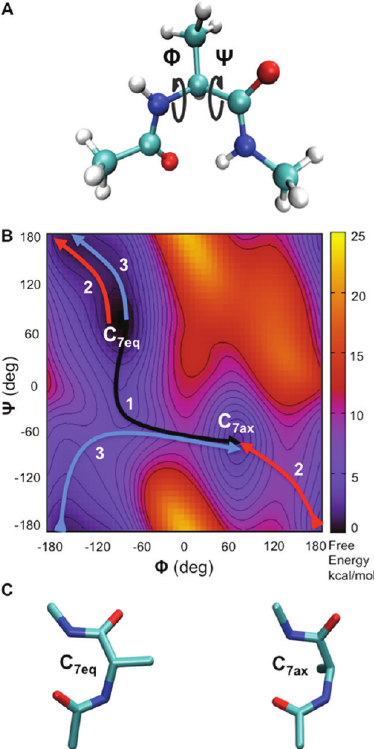

In [ ]:
import pandas as pd

df = pd.read_csv('ala2_distance_data.csv')

df.head(10)

In [ ]:
import seaborn as sns
sns.pairplot(df[['d4','d12','d13','state']],hue='state')

In [ ]:
X = df.filter(regex='d').values #we are selecting those features which contain the letter 'd'
X.shape

### Perform PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=4)
pca.fit(X)

### Explained Variance Ratio

In [ ]:
print(pca.explained_variance_ratio_)

for i in range(len(pca.explained_variance_ratio_)):
    print('PC %d: %0.2f'%(i+1,pca.explained_variance_ratio_[i]*100))

### Project the data along the 4 PCA components

In [ ]:
X_pca = pca.fit_transform(X)

In [ ]:
X_pca.shape

In [ ]:
y = df.filter(regex='state').values

In [ ]:
y.shape

In [ ]:
projected_data = np.concatenate((X_pca,y),axis=1)

In [ ]:
df_pca = pd.DataFrame(projected_data, columns=['PC 1','PC 2','PC 3','PC 4','state'])
df_pca.head()

In [ ]:
sns.pairplot(df_pca,hue='state')

In [ ]:
# @title Plotting code
def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$PC 1$")
    plt.ylabel("$PC 2$", rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)




# Classify the two states using SVM along PC1 and PC2

In [ ]:
from sklearn.svm import SVC

X_data = df_pca[['PC 1','PC 2']]
y_data = df_pca[['state']]

svm_clf = SVC(C=5, max_iter=10_000,kernel='rbf',random_state=42)
svm_clf.fit(X_data.values, y_data.values[:,0])

plot_predictions(svm_clf, [-0.2, 0.5, -0.2, 0.2])
plot_dataset(X_data.values, y_data.values[:,0], [-0.2, 0.5, -0.2, 0.2])

# Image analysis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA

# Load the image and convert it to grayscale
image = Image.open("cat.jpg").convert('L')
image_array = np.array(image)
plt.imshow(image_array, cmap='gray')


In [ ]:
# Perform PCA
n_components=0
pca = PCA(n_components=n_components)  # Choose the number of components
transformed_image = pca.fit_transform(image_array)

# Reconstruct the image
reconstructed_image = pca.inverse_transform(transformed_image)

# Display the original and reconstructed images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image_array, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Reconstructed Image ({} components)".format(n_components))
plt.imshow(reconstructed_image, cmap='gray')

plt.show()

In [ ]:
for i in range(len(pca.explained_variance_ratio_)):
  print(f"Eigenvalue {i+1}: {pca.explained_variance_ratio_[i]}" )

# TICA

In [ ]:
!pip install deeptime

In [ ]:
import numpy as np
from deeptime.decomposition import TICA

In [ ]:
from deeptime.data import ellipsoids

# create dataset instance
ellipsoids = ellipsoids(seed=17)
# discrete transitions
discrete_trajectory = ellipsoids.discrete_trajectory(n_steps=1000)
# corresponding observations
feature_trajectory = ellipsoids.map_discrete_to_observations(discrete_trajectory)

In [ ]:
tt = np.arange(len(feature_trajectory))

plt.figure()
plt.plot(tt,feature_trajectory[:,0])
plt.xlabel('t')
plt.ylabel('x')

plt.figure()
plt.plot(tt,feature_trajectory[:,1])
plt.xlabel('t')
plt.ylabel('y')

In [ ]:

f, axes = plt.subplots(1, 1, figsize=(5, 5), constrained_layout=True)
ax1 = axes

# scatter plot of samples
ax1.scatter(*(feature_trajectory.T), marker='.')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Example data samples');



In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=1).fit(feature_trajectory)  # fit the 2-dimensional data

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
projection = pca.transform(feature_trajectory)
ax1.plot(projection)
ax1.set_title('PCA projection of 2-dimensional trajectory')
ax1.set_xlabel('x')
ax1.set_ylabel('t')

dxy = pca.components_[0]  # dominant pca component

ax2.scatter(*(feature_trajectory.T), marker='.')
x, y = np.meshgrid(
    np.linspace(np.min(feature_trajectory[:, 0]), np.max(feature_trajectory[:, 0]), 4),
    np.linspace(np.min(feature_trajectory[:, 1]), np.max(feature_trajectory[:, 1]), 4)
)
plt.quiver(x,y,dxy[0],dxy[1])

ax2.set_aspect('equal')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Example data samples with dominant PCA component');

In [ ]:
tica = TICA(dim=1,  # fix projection dimension explicitly
    lagtime=1
)

tica_model = tica.fit(feature_trajectory, lagtime=1).fetch_model()

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(tica_model.transform(feature_trajectory))
ax1.set_title('TICA projection of 2-dimensional trajectory')
ax1.set_xlabel('x')
ax1.set_ylabel('t')

dxy = tica_model.singular_vectors_left[:, 0]  # dominant tica component

ax2.scatter(*(feature_trajectory.T), marker='.')
x, y = np.meshgrid(
    np.linspace(np.min(feature_trajectory[:, 0]), np.max(feature_trajectory[:, 0]), 4),
    np.linspace(np.min(feature_trajectory[:, 1]), np.max(feature_trajectory[:, 1]), 4)
)
plt.quiver(x, y, dxy[0], dxy[1])

ax2.set_aspect('equal')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Example data samples with dominant TICA component');